Phase Amplitude Coupling object defined
    extract phases (n_pha=50) and amplitudes (n_amps=50)
    true PAC estimation using Gaussian Copula PAC (gcPac)


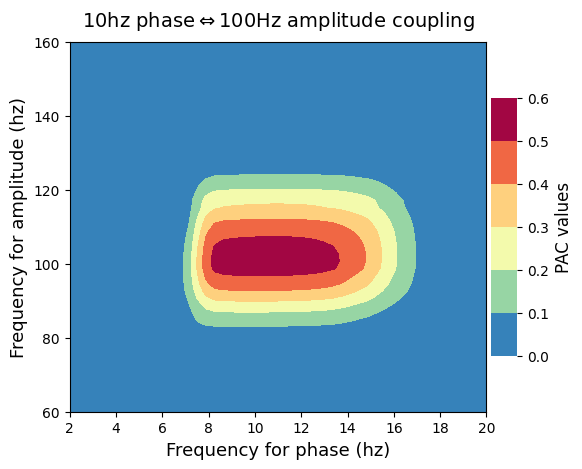

In [1]:
from torchpac import Pac
from torchpac.signals import pac_signals_tort

import matplotlib.pyplot as plt

# Dataset of signals artificially coupled between 10hz and 100hz :
n_epochs = 20   # number of trials
n_times = 4000  # number of time points
sf = 512.       # sampling frequency

# Create artificially coupled signals using Tort method :
data, time = pac_signals_tort(f_pha=10, f_amp=100, noise=2, n_epochs=n_epochs,
                              dpha=10, damp=10, sf=sf, n_times=n_times)

# Define a Pac object
p = Pac(idpac=(6, 0, 0), f_pha='hres', f_amp='hres',device="cuda:1")
# Filter the data and extract pac
xpac = p.filterfit(sf, data)

# plot your Phase-Amplitude Coupling :
p.comodulogram(xpac.mean(-1), cmap='Spectral_r', plotas='contour', ncontours=5,
               title=r'10hz phase$\Leftrightarrow$100Hz amplitude coupling',
               fz_title=14, fz_labels=13)
# export the figure
# plt.savefig('readme.png', bbox_inches='tight', dpi=300)
p.show()

In [2]:
import numpy as np

from torchpac import EventRelatedPac
from torchpac.signals import pac_signals_wavelet

import matplotlib.pyplot as plt

In [3]:
n_epochs = 300
n_times = 1000
sf = 1000.
x1, tvec = pac_signals_wavelet(f_pha=10, f_amp=100, n_epochs=n_epochs, noise=2,
                               n_times=n_times, sf=sf)

# Second signal : one second of random noise
x2 = np.random.rand(n_epochs, 1000)

# now, concatenate the two signals across the time axis
x = np.concatenate((x1, x2), axis=1)
time = np.arange(x.shape[1]) / sf

In [4]:
# define an ERPAC object
p = EventRelatedPac(f_pha=[9, 11], f_amp='hres',device="cuda:1")

# extract phases and amplitudes
pha = p.filter(sf, x, ftype='phase', n_jobs=1)
amp = p.filter(sf, x, ftype='amplitude', n_jobs=1)

Event Related PAC object defined


    Compute ERPAC (Voytek et al. 2013)
    Correct p-values for multiple-comparisons using fdr correction of MNE-Python
    Compute Gaussian-Copula ERPAC


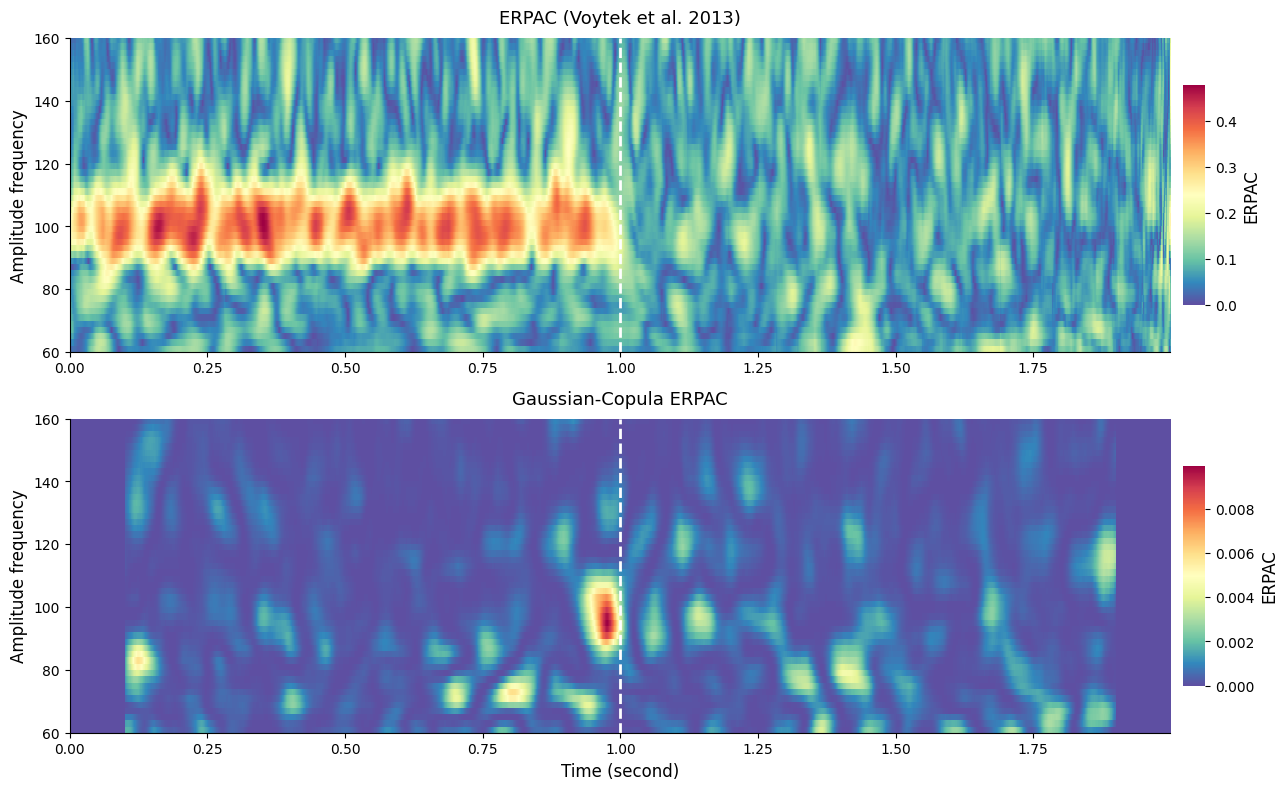

In [5]:
methods = ['circular', 'gc']

plt.figure(figsize=(14, 8))
for n_m, m in enumerate(methods):
    # compute the erpac
    erpac = p.fit(pha, amp, method=m, smooth=100, n_jobs=-1).squeeze()

    # plot
    plt.subplot(len(methods), 1, n_m + 1)
    p.pacplot(erpac, time, p.yvec, xlabel='Time (second)' * n_m,
              cmap='Spectral_r', ylabel='Amplitude frequency', title=p.method,
              cblabel='ERPAC', vmin=0., rmaxis=True)
    plt.axvline(1., linestyle='--', color='w', linewidth=2)

plt.tight_layout()
p.show()